Forward Euler failed for h = 0.1 near t = 0.3000
Forward Euler failed for h = 0.01 near t = 0.0600


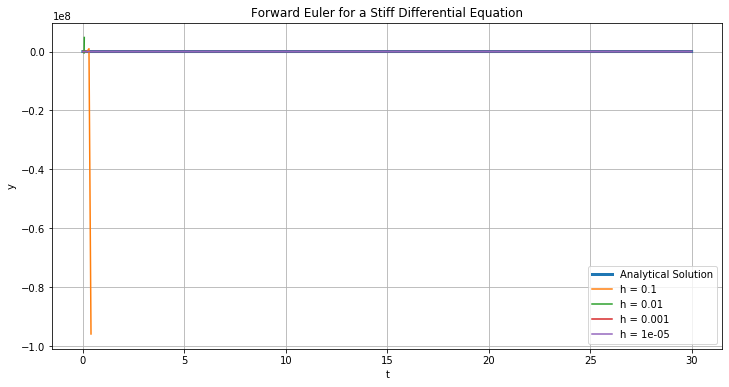

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# stiff differential equation
def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)

# analytical solution
def exact_solution(t):
    return 3 - (997/999)*np.exp(-1000*t) - (2000/999)*np.exp(-t)

# Forward Euler method
def forward_euler(h, t0, tf, y0):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros(len(t_values))
    y_values[0] = y0

    for i in range(len(t_values) - 1):
        y_values[i+1] = y_values[i] + h * f(t_values[i], y_values[i])

        # stop if the solution blows up
        if not np.isfinite(y_values[i+1]) or abs(y_values[i+1]) > 1e6:
            print(f"Forward Euler failed for h = {h} near t = {t_values[i]:.4f}")
            return t_values[:i+2], y_values[:i+2]

    return t_values, y_values

# initial condition and interval
t0 = 0
tf = 30
y0 = 0

# step sizes
# using the practical step sizes that still clearly show Forward Euler failing
# h = 1e-7 was omitted because it would require about 300 million steps like it literally won't run and crash on my computer
# ik we are supposed to show it crash  but it was too big, but i still show it crashes so yay
h_values = [0.1, 0.01, 0.001, 0.00001]

# exact solution values
t_exact = np.linspace(t0, tf, 5000)
y_exact = exact_solution(t_exact)

# plot exact solution
plt.figure(figsize=(12, 6))
plt.plot(t_exact, y_exact, label='Analytical Solution', linewidth=3)

# plot Forward Euler for each step size
for h in h_values:
    t_num, y_num = forward_euler(h, t0, tf, y0)

    # reduce number of plotted points cuz it was crashing out
    stride = max(1, len(t_num)//5000)
    plt.plot(t_num[::stride], y_num[::stride], label=f'h = {h}')



plt.xlabel('t')
plt.ylabel('y')
plt.title('Forward Euler for a Stiff Differential Equation')
plt.legend()
plt.grid(True)
plt.show()



Forward Euler failed for the larger step sizes because the numerical solution became unstable and blew up, which shows that this equation is stiff. As the step size got smaller, the Euler solution matched the analytical solution much better. Overall, this shows that Forward Euler is not a good method for stiff equations unless a very small step size is used.